https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow

# import tensorflow as tf
# tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
# from msi.gaussian_mixture import architecture
# from deep_lss.utils import configuration

from msi.utils import preprocessing, plotting
from msfm.utils import prior, parameters, files, logger, observation

# load network predictions

### v4

In [3]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/config.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # lensing only

# # large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [4]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [5]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing"

# # delta loss #####################################################################################################

# # longest run, 300k steps with evaluations every 10k
# # model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# # model_dir = "delta/2024-02-06_11-02-57_resnet_vanilla"
# # model_dir = "delta/2024-02-08_08-21-34_resnet_vanilla"

# # biggest run yet, 100k, 200k and 300k evaluations
# # model_dir = "delta/2024-02-09_05-23-03_resnet_vanilla"

# # new, smaller run with evaluations every 10k steps (cashed, buggy)
# # model_dir = "delta/2024-02-12_00-37-01_resnet_vanilla"

# # model_dir = "delta/2024-02-12_06-56-43_resnet_vanilla"

# # new, smaller run with evaluations every 10k steps 
# # model_dir = "likelihood/2024-02-12_02-26-58_resnet_vanilla"

# # vision transformer, delta loss
# # model_dir = "delta/2024-02-13_07-42-20_vit_vanilla"

# # graph transformer, delta loss
# # model_dir = "delta/2024-02-14_02-57-06_gt_vanilla"

# # 1d convolutions, delta loss
# # model_dir = "delta/2024-02-14_01-54-13_oneD_vanilla"

# # with warmup and cosine decay for 100k steps
# model_dir = "lensing/delta/2024-02-22_03-37-44_resnet_vanilla"

# # likelihood loss ################################################################################################

# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

# # vision transformer
# # model_dir = "likelihood/2024-02-15_02-41-25_vit_vanilla"


# n_steps = 200000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

In [6]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/combined"

# # delta loss
# # model_dir = "delta/2024-02-02_00-28-48_resnet_vanilla"


# # likelihood loss
# # model_dir = "likelihood/2024-01-30_07-41-40_resnet_vanilla"
# model_dir = "likelihood/2024-02-01_09-02-59_resnet_vanilla"

# n_steps = 200000
# # params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

# v7

### lensing only

In [7]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v7/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"

# # delta loss #####################################################################################################

# # # with warmup and cosine decay for 100k steps
# # model_dir = "delta/2024-02-22_03-37-44_resnet_vanilla"

# # # with warmup, cosine decay and validation loss, but crashed after 80k steps (visionary-grass-327)
# # model_dir = "delta/2024-02-29_04-19-40_resnet_vanilla"

# # # like the above, but without validation loss (wobbly-durian-328)
# # model_dir = "delta/2024-02-29_05-09-44_resnet_vanilla"

# # # constant learning rate and validation loss for 100k steps (noble-snowball-334)
# # model_dir = "delta/2024-03-02_10-21-45_resnet_vanilla"

# # icy-vortex-344, cosine decay, but reasonable validation loss, jac_weight = 10
# # training loss = -65.46736907958984
# # validation loss = -18.688838958740234
# # model_dir = "delta/2024-03-13_03-40-37_resnet_vanilla"

# # skilled-salad-343, cosine decay, but reasonable validation loss, jac_weight = 100
# # training loss = -58.87385559082031
# # validation loss = -19.380346298217773
# # model_dir = "delta/2024-03-13_03-40-30_resnet_vanilla"

# # curant-cobbler-377, cosine decay, jac_weight = 100, no second to last MLP layer in the regression head
# # training loss = -61.6363525390625
# # validation loss = -17.869802474975586
# model_dir = "delta/2024-03-14_10-10-52_resnet_vanilla"

# # bright-yogurt-408, cosine decay, jac_weight = 100, convolutional regression head (only difference compared to skilled-salad-343)
# # training loss = -64.59732055664062
# # validation loss = -18.545400619506836
# # model_dir = "delta/2024-03-15_08-48-50_resnet_vanilla"

# # polwar-meadow-494, ViT with small patch size
# # model_dir = "delta/2024-03-22_01-19-27_resnet_vanilla"

# # daily-cloud-495, ViT with larger patch size
# # model_dir = "delta/2024-03-22_01-19-30_resnet_vanilla"

# # likelihood loss ################################################################################################

# # # constant learning rate and validation for 100k steps (classic-capybara-333)
# # model_dir = "likelihood/2024-03-01_13-43-31_resnet_vanilla"

# # n_steps = 300000
# # n_steps = 101485
# n_steps = 100000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

# v8

### lensing only

In [8]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v8/lensing"

# # delta loss #####################################################################################################

# # glad-cloud-1011, like curant-cobbler-377, but with the new training set
# # model_dir = "delta/2024-04-22_06-50-39_resnet_vanilla"

# # grateful-firefly-1015, like glad-cloud-1011, but with a constant learning rate
# # model_dir = "delta/2024-04-24_00-27-06_resnet_vanilla"

# # atomic-dream-1016, like glad-cloud-1011, but with twice the number of channels
# # model_dir = "delta/2024-04-24_03-45-06_resnet_vanilla"

# # deep-deluge-1017, like glad-cloud-1011, but without any smoothing (full nside 512/ell_max 1500)
# # model_dir = "delta/2024-04-25_03-29-23_resnet_vanilla"

# # soft-bush-1019, like deep-deluge-1017, but with 60 instead of 20 neighbors in the graph
# # model_dir = "delta/2024-04-25_04-48-49_resnet_vanilla"

# # no smoothing

# # northern-elevator-1024: no smoothing, warmup followed by constant learning rate, 60 neighbors in graph, 100k steps, larger batch size
# # model_dir = "delta/2024-04-26_05-10-36_resnet_vanilla"

# # feasible-monkey-1026: Like northern-elevator-1024, but with a local batch size of four
# model_dir = "delta/2024-04-26_05-39-31_resnet_vanilla"

# n_steps = 50_000
# # n_steps = 55_000
# # n_steps = 60_000
# # n_steps = 65_000
# # n_steps = 100_000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### clustering only

In [9]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v8/clustering"

# # delta loss #####################################################################################################

# # # revived-blaze-1027, for PASC
# # model_dir = "delta/2024-04-26_05-50-43_resnet_vanilla"
# # n_steps = 80_000

# # # rare-feather-1036, like revived-blaze-1027, but with no l_min 
# # model_dir = "delta/2024-05-06_10-56-24_resnet_vanilla"
# # n_steps = 70_000

# # # rare-yogurt-1038, like rare-feather-1036, but with 1% white noise
# # model_dir = "delta/2024-05-12_01-50-44_resnet_vanilla"
# # n_steps = 60_000

# # still-galaxy-1037, like rare-feather-1036, but with 1% white noise
# model_dir = "delta/2024-05-10_12-33-20_resnet_vanilla"
# n_steps = 80_000

# params = ["Om", "s8", "w0", "bg", "n_bg"]


### combined probes

In [10]:
# # conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v8/combined"

# # # delta loss #####################################################################################################

# # still-glitter-1023: normal smoothing, warmup followed by constant learning rate, 60 neighbors in graph, 100k steps, larger batch size
# model_dir = "delta/2024-04-26_05-10-35_resnet_vanilla"

# # # n_steps = 100_000
# # params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### for PASC poster

In [11]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v8"

# # delta loss #####################################################################################################

# # # lensing
# # model_dir = "lensing/delta/2024-04-26_05-50-54_resnet_vanilla"
# # params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# # n_steps = 100_000

# # # clustering
# # model_dir = "clustering/delta/2024-04-26_05-50-43_resnet_vanilla"
# # params = ["Om", "s8", "w0", "bg", "n_bg"]
# # n_steps = 80_000

# # combined
# model_dir = "combined/delta/2024-04-26_17-18-07_resnet_vanilla"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# n_steps = 50_000

# v9

### clustering

In [12]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v9/clustering"

# # delta loss #####################################################################################################

# # # earnest-wood-1039 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/nmhf2f7f), 10% of noise
# # model_dir = "delta/2024-07-17_09-27-28_resnet_vanilla"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/resnet_vanilla.yaml"
# # n_steps = 60_000

# # fresh-sky-1040 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/0r0mzpo9), 1% of noise
# model_dir = "delta/2024-07-18_10-16-57_resnet_vanilla"
# net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/resnet_vanilla.yaml"
# n_steps = 60_000

# params = ["Om", "s8", "w0", "bg", "n_bg"]

# v10

### lensing

In [13]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v10/lensing"

# # # mutual info loss ###############################################################################################

# # # # eternal-tree-1042 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/rh93pfh8/overview) 
# # # # default
# # # model_dir = "mutual_info/2024-08-26_06-07-27_deepsphere_default"
# # # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/lensing/deepsphere_default.yaml"
# # # n_steps = 100_000

# # # dulcet-dragon-1048 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/xhb0e1xg/overview)
# # # flat learning rate instead of cosine decay
# # # model_dir = "mutual_info/2024-08-28_00-40-10_deepsphere_default"
# # # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/lensing/deepsphere_default.yaml"
# # # n_steps = 100_000

# # # fisher info loss ###############################################################################################

# # # # # valiant-forest-1041 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/na3hr7y4/overview)
# # # trash because of dropout
# # # model_dir = "delta/2024-08-26_06-07-05_deepsphere_default"
# # # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/lensing/deepsphere_default.yaml"
# # # n_steps = 100_000

# # # # golden-darkness-1054 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/e7jfz286/overview)
# # # # good because of a lack of dropout
# # # model_dir = "delta/2024-08-29_07-43-55_deepsphere_default"
# # # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/lensing/deepsphere_no_dropout.yaml"
# # # n_steps = 100_000

# # divine-paper-1057 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/jpqckpa0/overview)
# # no dropout, but with Gaussian white noise and gradient clipping reduced to 1.0
# model_dir = "delta/2024-08-31_18-48-28_deepsphere_default"
# net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/lensing/deepsphere_no_dropout.yaml"
# n_steps = 100_000

# # # clean-sunset-1045 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/9z04yyv8/overview)

# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### clustering

In [14]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v10/clustering"
# base_dir = "/pscratch/sd/a/athomsen/run_files/v10/linear_bias/clustering"
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v10/linear_bias_octant/clustering"

# # mutual info loss ###############################################################################################

# # # deft-puddle-1049 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/r62vjlo9/overview)
# # model_dir = "mutual_info/2024-08-28_00-40-26_deepsphere_default"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/lensing/deepsphere_default.yaml"
# # n_steps = 90_000

# # # lyric-cosmos-1053 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/r62vjlo9/overview)
# # # smaller batch size, more gradient clipping, more steps
# # model_dir = "mutual_info/2024-08-29_02-37-49_deepsphere_default"
# # n_steps = 190_000

# # # rich-dust-1071 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/adhedyyr/overview)
# # model_dir = "/pscratch/sd/a/athomsen/run_files/v10/linear_bias_octant/clustering/mutual_info/2024-09-08_10-01-44_deepsphere_default"
# # n_steps = 140_000

# # fluent-armadillo-1074 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/w8vi43o2/overview)
# # more noise, less smoothing, but roughly the same scale-cut as lyric-cosmos-1053
# model_dir = "mutual_info/2024-10-04_08-12-55_deepsphere_default"
# n_steps = 130_000

# # fisher info loss ###############################################################################################

# # # astral-snowball-1050 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/165eicwm/overview)
# # model_dir = "delta/2024-08-28_02-52-15_deepsphere_default"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/deepsphere_no_dropout.yaml"
# # n_steps = 70_000

# params = ["Om", "s8", "w0", "bg", "n_bg"]

### combined

In [15]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v10/combined"

# # mutual info loss ###############################################################################################

# # # gallant-night-1058 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/8r5b5ei0/overview)
# # # lemon-blaze-1060 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/5gkmbmiw/overview) for more steps
# # model_dir = "mutual_info/2024-08-31_18-48-28_deepsphere_default"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/deepsphere_default.yaml"
# # # n_steps = 170_000
# # # n_steps = 310_000
# # n_steps = 340_000

# # rose-tree-1063 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/m3ylvrui/overview)
# # cosine decay instead of flat learning rate
# # model_dir = "mutual_info/2024-09-02_06-48-22_deepsphere_default"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/deepsphere_default.yaml"
# # n_steps = 150_000

# # fisher info loss ###############################################################################################

# # # mild-brook-1065 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3hiqzsqq/overview)
# # # this run is trash and I don't understand why
# # model_dir = "delta/2024-09-02_09-33-38_deepsphere_default"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/deepsphere_default.yaml"
# # n_steps = 30_000

# # # rich-dew-1066 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/ybqd73xf/overview)
# # # no Gaussian white noise at all
# # model_dir = "delta/2024-09-03_03-11-03_deepsphere_default"
# # net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/deepsphere_no_dropout.yaml"
# # n_steps = 50_000

# # vocal-water-1067 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/xf815rzo/overview)
# # Like rich-dew-1066, but with Gaussian white noise
# model_dir = "delta/2024-09-03_05-47-33_deepsphere_default"
# net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/deepsphere_no_dropout.yaml"
# n_steps = 50_000

# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

# v11

### clustering

In [16]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # # sunny-sea-1078 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/kt4ng005/overview)
# # # soft cut, but similar l_max as earnest-flower-1077
# # model_dir = "/pscratch/sd/a/athomsen/run_files/v11/extended/clustering/mutual_info/2024-10-12_04-01-53_deepsphere_default"
# # n_steps = 130_000

# # # earnest-flower-1077 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/7nl9qkh8/overview)
# # # hard cut, but similar l_max as sunny-sea-1078
# # model_dir = "/pscratch/sd/a/athomsen/run_files/v11/extended_hard_cut/clustering/mutual_info/2024-10-12_04-01-53_deepsphere_default"
# # n_steps = 200_000

# # # northern-spaceship-1079 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/kt4ng005/overview)
# # # soft cut like sunny-sea-1078, but n_summary = n_params (instead of 2 * n_params)
# # model_dir = "/pscratch/sd/a/athomsen/run_files/v11/extended/clustering/mutual_info/2024-10-18_17-59-26_deepsphere_default"
# # n_steps = 130_000

# # vague-sea-1080 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/kt4ng005/overview)
# # soft cut with a lot of smoothing
# model_dir = "/pscratch/sd/a/athomsen/run_files/v11/extended/clustering/mutual_info/2024-10-20_01-03-44_deepsphere_default"
# n_steps = 110_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# # params = ["Om", "s8", "w0"]
# # params = ["Om", "s8"]

# v12

### clustering

In [17]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # fanciful-plasma-1081 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/xus25zc2/overview)
# # very conservative like vague-sea-1080, but with (DeepLSS-style) quadratic biasing
# model_dir = "/pscratch/sd/a/athomsen/run_files/v12/nonlinear/clustering/mutual_info/2024-10-26_18-21-39_deepsphere_default"
# n_steps = 100_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

# v13

### lensing

In [18]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # worldly-cherry-1082 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/axisu9uv/overview)
# # conservative firwst v13 run
# model_dir = "/pscratch/sd/a/athomsen/run_files/v13/extended/lensing/mutual_info/2025-01-11_07-17-28_deepsphere_default"
# # n_steps = 100_000
# n_steps = 200_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

### clustering

In [19]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v13/extended.yaml")
# base_dir = ""

# # # mutual info loss ###############################################################################################

# # # polished-snow-1083 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/8bptajqu/overview)
# # # very conservative first v13 run
# # model_dir = "/pscratch/sd/a/athomsen/run_files/v13/extended/clustering/mutual_info/2025-01-11_07-17-28_deepsphere_default"
# # n_steps = 100_000

# # # wandering-shadow-1084 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/z9to945a/overview)
# # # even more conservative run, 32mpc/h smoothing with 10% noise -> l_max = [82, 121, 158, 189]
# # model_dir = "/pscratch/sd/a/athomsen/run_files/v13/extended/clustering/mutual_info/2025-01-16_00-50-58_deepsphere_default"
# # # n_steps = 80_000
# # # n_steps = 110_000
# # # n_steps = 120_000
# # # n_steps = 130_000
# # # n_steps = 140_000
# # n_steps = 170_000

# # confused-sun-1087 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/ekt8evre/overview)
# # less conservative run, 32mpc/h smoothing with 1% noise -> l_max = [133, 195, 255, 305]
# model_dir = "/pscratch/sd/a/athomsen/run_files/v13/extended/clustering/mutual_info/2025-02-01_01-16-48_deepsphere_default"
# # n_steps = 110_000
# # n_steps = 140_000
# n_steps = 190_000

# # # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# v14

### lensing

In [20]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
base_dir = ""

# mutual info loss ###############################################################################################

# young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
# first v14 run
model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default"
# n_steps = 100_000
# n_steps = 200_000
n_steps = 300_000
# n_steps = 400_000

# fisher info loss ###############################################################################################

params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

### combined

In [21]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # grateful-universe-1093 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/tun9hdvl/overview)
# # mythical-cantina-1094 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/6w6yju8t/overview)
# # first v14 combined probes run
# model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default"
# # n_steps = 100_000
# n_steps = 200_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

### general

In [22]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir,
    model_dir,
    n_steps,
    with_fidu=False,
    # n_params=len(params), 
    # n_perms_per_cosmo=4
)

if params == ["Om", "s8"]:
    grid_cosmos = grid_cosmos[:,:2]
if params == ["Om", "s8", "w0"]:
    grid_cosmos = grid_cosmos[:,:3]

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)

label = f"{n_steps}_steps_likelihood"
# label = f"{n_steps}_steps_posterior"

25-05-12 06:58:20 input_output INF   Array shapes: 
25-05-12 06:58:20 input_output WAR   Could not find fiducial/vali/pred in /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_300000.h5 
25-05-12 06:58:20 input_output WAR   Could not find fiducial/vali/i_example in /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_300000.h5 
25-05-12 06:58:20 input_output WAR   Could not find fiducial/vali/i_noise in /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_300000.h5 
25-05-12 06:58:20 input_output INF   grid/pred          = (2500, 80, 12) 
25-05-12 06:58:20 input_output INF   grid/cosmo         = (2500, 80, 6) 
25-05-12 06:58:20 input_output INF   grid/i_example     = (2500, 80) 
25-05-12 06:58:20 input_output INF   grid/i_noise       = (2500, 80) 
25-05-12 06:58:20 input_output INF   grid/i_sobol       = (250

# likelihood Flow $p(x|\theta)$

### architecture

In [23]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    # n_layers=2,
    # hidden_dim=512,
    hidden_dim=128,
    svd_kwargs={},
    sigmoids_kwargs={
        # "n_sigmoids": 32,
        "n_sigmoids": 8,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)


transform = architecture.get_lipschitz_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
)

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    # label=label + "_" + str(params).replace(" ", "").replace("'", ""),
    # label=label + "_" + str(params).replace(" ", "").replace("'", "") + "_lipschitz",
    # label=label + "_small_sigmoid",
    # label=label + "_lipschitz",
    # load_existing=False,
    load_existing=True,
)

25-05-12 06:58:21 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/300000_steps_likelihood/likelihood_flow 
25-05-12 06:58:21 likelihood_f INF   Initialized the normalizing flow 
25-05-12 06:58:21 likelihood_f INF   Running on device cuda with default float torch.float32 
25-05-12 06:58:21 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/300000_steps_likelihood/likelihood_flow/likelihood_flow.pt 


### training

In [24]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 4 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-6},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# posterior Flow $p(\theta|x)$

### architecture

In [25]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 32

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=64,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=theta_dim,
# )

# # transform = architecture.get_sigmoids_transform(
# #     feature_dim=theta_dim,
# #     context_embedding_dim=context_embedding_dim,
# #     n_layers=4,
# #     hidden_dim=512,
# #     svd_kwargs={},
# #     sigmoids_kwargs={
# #         "n_sigmoids": 32,
# #         "num_blocks": 3,
# #         "dropout_probability": 0.0,
# #     }
# # )

# transform = architecture.get_lipschitz_transform(
#     feature_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     hidden_dim=256,
# )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     out_dir=out_dir, 
#     # label=label,
#     label=label + "_wide_lipschitz",
#     # label=label + "_tight",
#     # label=label + "_wide",
#     load_existing=False,
#     # load_existing=True,
# )

### training

In [26]:
# # only wide prior
# i_in_wide = grid_cosmos.shape[0]//2
# grid_cosmos = grid_cosmos[:i_in_wide]
# grid_preds = grid_preds[:i_in_wide]

# # # only tight prior
# # grid_cosmos = grid_cosmos[i_in_wide:]
# # grid_preds = grid_preds[i_in_wide:]

In [27]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 4 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_cosmos,
#     theta=grid_preds,
#     # n_epochs=100,
#     n_epochs=300,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-6},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# Gaussian Mixture Model $p(x|\theta)$

### architecture

In [28]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_preds.shape[-1],
#     n_theta=grid_cosmos.shape[1],
#     n_gaussians=8,
#     n_units=256,
#     n_layers=8,
#     activation="relu",
#     dropout_rate=0.1,
# )

# model = LikelihoodGMM(
#     params, 
#     conf,
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     load_existing=False,
# )

### training

In [29]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 8 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=1_000,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # schedule
#     # scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
#     scheduler_kwargs={"factor": 0.8, "patience": 10, "cooldown": 5, "min_lr": 1e-6},
#     # scheduler_kwargs={},
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

In [30]:
# grid_preds_sample = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     # grid_preds_true=file_dict["grid/pred"], 
#     # grid_cosmos=file_dict["grid/cosmo"],
#     grid_preds_true=grid_preds,
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     n_cosmos=5_000,
#     do_dlss=False,
#     do_eecp=True,
#     do_tarp=True,
# )

# contours

### observations

CosmoGrid internal

In [31]:
grid_preds.shape

(200000, 12)

In [32]:
# obs_dict = {}

# shift = 5
# n_examples = 4
# i_fidu = 0

# # for i_fidu in range(n_examples):
# #     obs_dict[f"fiducial_{i_fidu}"] = {
# #         "pred": fidu_preds[i_fidu], 
# #         "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# #     }

# # obs_dict[f"fiducial_{i_fidu}"] = {
# #     "pred": fidu_preds[i_fidu], 
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_mean"] = {
# #     "pred": np.mean(fidu_preds[shift*n_examples:(1+shift)*n_examples], axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_mean_all"] = {
# #     "pred": np.mean(fidu_preds, axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_stack"] = {
# #     "pred": np.stack([fidu_preds[i] for i in range(shift*n_examples, (1+shift)*n_examples)], axis=0), 
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_median"] = {
# #     "pred": np.median(fidu_preds, axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# for i_grid in range(n_examples):
#     i_grid *= 80
#     obs_dict[f"grid_i{i_grid}"] = {
#         "pred": grid_preds[i_grid],
#         "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
#     }

# # i_grid = 99
# # obs_dict[f"grid_{i_grid}"] = {
# #     "pred": grid_preds[i_grid],
# #     "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
# # }

In [33]:
# obs_dict = {}

# obs_label = "CosmoGrid_qbg=1_mean"
# # obs_label = "CosmoGrid_qbg=2_mean"
# # obs_label = "CosmoGrid_qbg=-3_mean"
# obs_dict[obs_label] = {
#     "pred": np.squeeze(file_dict[f"mocks/pred/{obs_label}"]),
#     # "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": 1.8, "bg2": 1.9, "bg3": 2.0, "bg4": 2.1},
# }

In [34]:
# obs_dict = {}

# qbgs = np.round(np.arange(-1, 1.2, 0.2), decimals=1)
# for qbg in qbgs:
#     # obs_label = f"CosmoGrid_qbg={qbg}"
#     obs_label = f"CosmoGrid_qbg={qbg},bg=high"
#     obs_dict[obs_label] = {
#         "pred": np.squeeze(file_dict[f"mocks/pred/{obs_label}"]),
#         # "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
#         "point": {"Om": 0.26, "s8": 0.84, "w0": -1, "bg1": 1.8, "bg2": 1.9, "bg3": 2.0, "bg4": 2.1},
#     }

In [35]:
# obs_dict = {}

# # get cosmogrid cosmologies
# data = h5py.File('/global/cfs/cdirs/des/cosmogrid/CosmoGridV1_metainfo.h5','r')
# cosmo_arr = data['parameters/grid'][()]

# grid_cosmo_paths = [item.astype('str').split('/')[-2] for item in cosmo_arr['path_par']]
# cosmo_params_cosmogridv11 = np.c_[cosmo_arr['Om'].astype('float'),cosmo_arr['s8'].astype('float'),cosmo_arr['w0'].astype('float')]

# i_sobols = [0, 38, 654, 710]

# cosmo_params_grid = cosmo_params_cosmogridv11[i_sobols]

# bg_dict = [
#     {"bg1": 1.34, "bg2": 1.42, "bg3": 1.50, "bg4": 1.57},
#     {"bg1": 1.05, "bg2": 0.95, "bg3": 2.10, "bg4": 1.87},
#     {"bg1": 1.74, "bg2": 2.20, "bg3": 1.50, "bg4": 2.57},
#     {"bg1": 2.34, "bg2": 2.42, "bg3": 0.99, "bg4": 1.01},
# ]
# # ia_dict = [
# #     {"Aia": -1.0, "n_Aia": 1.4, "bta": np.nan},
# #     {"Aia": 0.0, "n_Aia": 0.0, "bta": np.nan},
# #     {"Aia": 1.3, "n_Aia": -2.5, "bta": np.nan},
# #     {"Aia": -2.0, "n_Aia": 1.3, "bta": np.nan},
# # ]

# for j, i_sobol in enumerate(i_sobols):
#     obs_dict[f"grid_{i_sobol}_stack"] = {
#         "pred": np.squeeze(file_dict[f"mocks/pred/grid_{i_sobol}"]),
#         # "point": {"Om": cosmo_params_grid[j,0], "s8": cosmo_params_grid[j,1], "w0": cosmo_params_grid[j,2], **ia_dict[j]},
#         "point": {"Om": cosmo_params_grid[j,0], "s8": cosmo_params_grid[j,1], "w0": cosmo_params_grid[j,2], **bg_dict[j]},
#     }

# # for j, i_sobol in enumerate(i_sobols):
# # # for j, i_sobol in enumerate(i_sobols[:1]):
# #     obs_dict[f"grid_{i_sobol}"] = {
# #         "pred": np.squeeze(file_dict[f"mocks/pred/grid_{i_sobol}"][0]),
# #         "point": {"Om": cosmo_params_grid[j,0], "s8": cosmo_params_grid[j,1], "w0": cosmo_params_grid[j,2], **bg_dict[j]},
# #         # "point": {"Om": cosmo_params_grid[j,0], "s8": cosmo_params_grid[j,1], "w0": cosmo_params_grid[j,2], **ia_dict[j]},
# #     }


DES footprint

In [36]:
obs_dict = {}

Aia_dict = {"Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Buzzard"]),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **Aia_dict},
# }
# print(np.squeeze(file_dict["mocks/pred/Buzzard"]))

for i in [0, 5, 8, 11]:
    obs_dict[f"Buzzard_{i}"] = {
        "pred": np.squeeze(file_dict[f"mocks/pred/Buzzard_{i}"]),
        "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **Aia_dict},
    }

In [37]:
# obs_dict = {}

# bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# # bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan, "qbg1": np.nan, "qbg2": np.nan, "qbg3": np.nan, "qbg4": np.nan}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Buzzard"]),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

# obs_dict["Cardinal"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Cardinal"]),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

# # buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# # buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# # buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# # buzzard_flock_preds = []
# # for i, buzzard_flock_label in enumerate(buzzard_flock_labels):
# #     buzzard = np.squeeze(file_dict[f"mocks/pred/{buzzard_flock_label}"])
# #     buzzard_flock_preds.append(buzzard)
    
# #     obs_dict[f"Buzzard_{i}"] = {
# #         "pred": buzzard,
# #         "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# #     }
    
# # buzzard_flock_stack = np.stack(buzzard_flock_preds, axis=0)
# # obs_dict["Buzzard_flock_stack"] = {
# #     "pred": buzzard_flock_stack,
# #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# # }

# # buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)
# # obs_dict["Buzzard_flock_mean"] = {
# #     "pred": buzzard_flock_mean,
# #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# # }

In [38]:
# obs_dict = {}

# bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}

# for i in range(8):
#     obs_dict[f"Cardinal_noise_{i}"] = {
#         "pred": np.squeeze(file_dict[f"mocks/pred/Cardinal_noise_{i}"]),
#         "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
#     }

Octant footprint

In [39]:
# obs_dict["MICE"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/MICE"]),
#     "point": {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

# obs_dict["Euclid"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Euclid"]),
#     "point": {"Om": 0.319, "s8": 0.83, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

### MCMC and plotting


Starting with mock observation Buzzard_0
25-05-12 06:58:23 likelihood_f INF   Sampling the posterior from a single observation 
25-05-12 06:58:23      mcmc.py INF   Initial values in prior: False 
25-05-12 06:58:23      mcmc.py INF   Starting the burn in MCMC chain (500 steps) 


100%|██████████| 500/500 [00:54<00:00,  9.22it/s]

25-05-12 06:59:17      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [01:57<00:00,  8.50it/s]

25-05-12 07:01:15      mcmc.py INF   MAP parameters: {'Om': 0.115, 's8': 0.941, 'w0': -0.344, 'Aia': -1.766, 'n_Aia': 2.993, 'bta': 0.001} 
25-05-12 07:01:15      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/300000_steps_likelihood/likelihood_flow/chain_Buzzard_0.npy 


...

  0%|          | 0/15 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:648: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


  0%|          | 0/15 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:648: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


25-05-12 07:10:02  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/300000_steps_likelihood/likelihood_flow/contours_Buzzard_11.png 


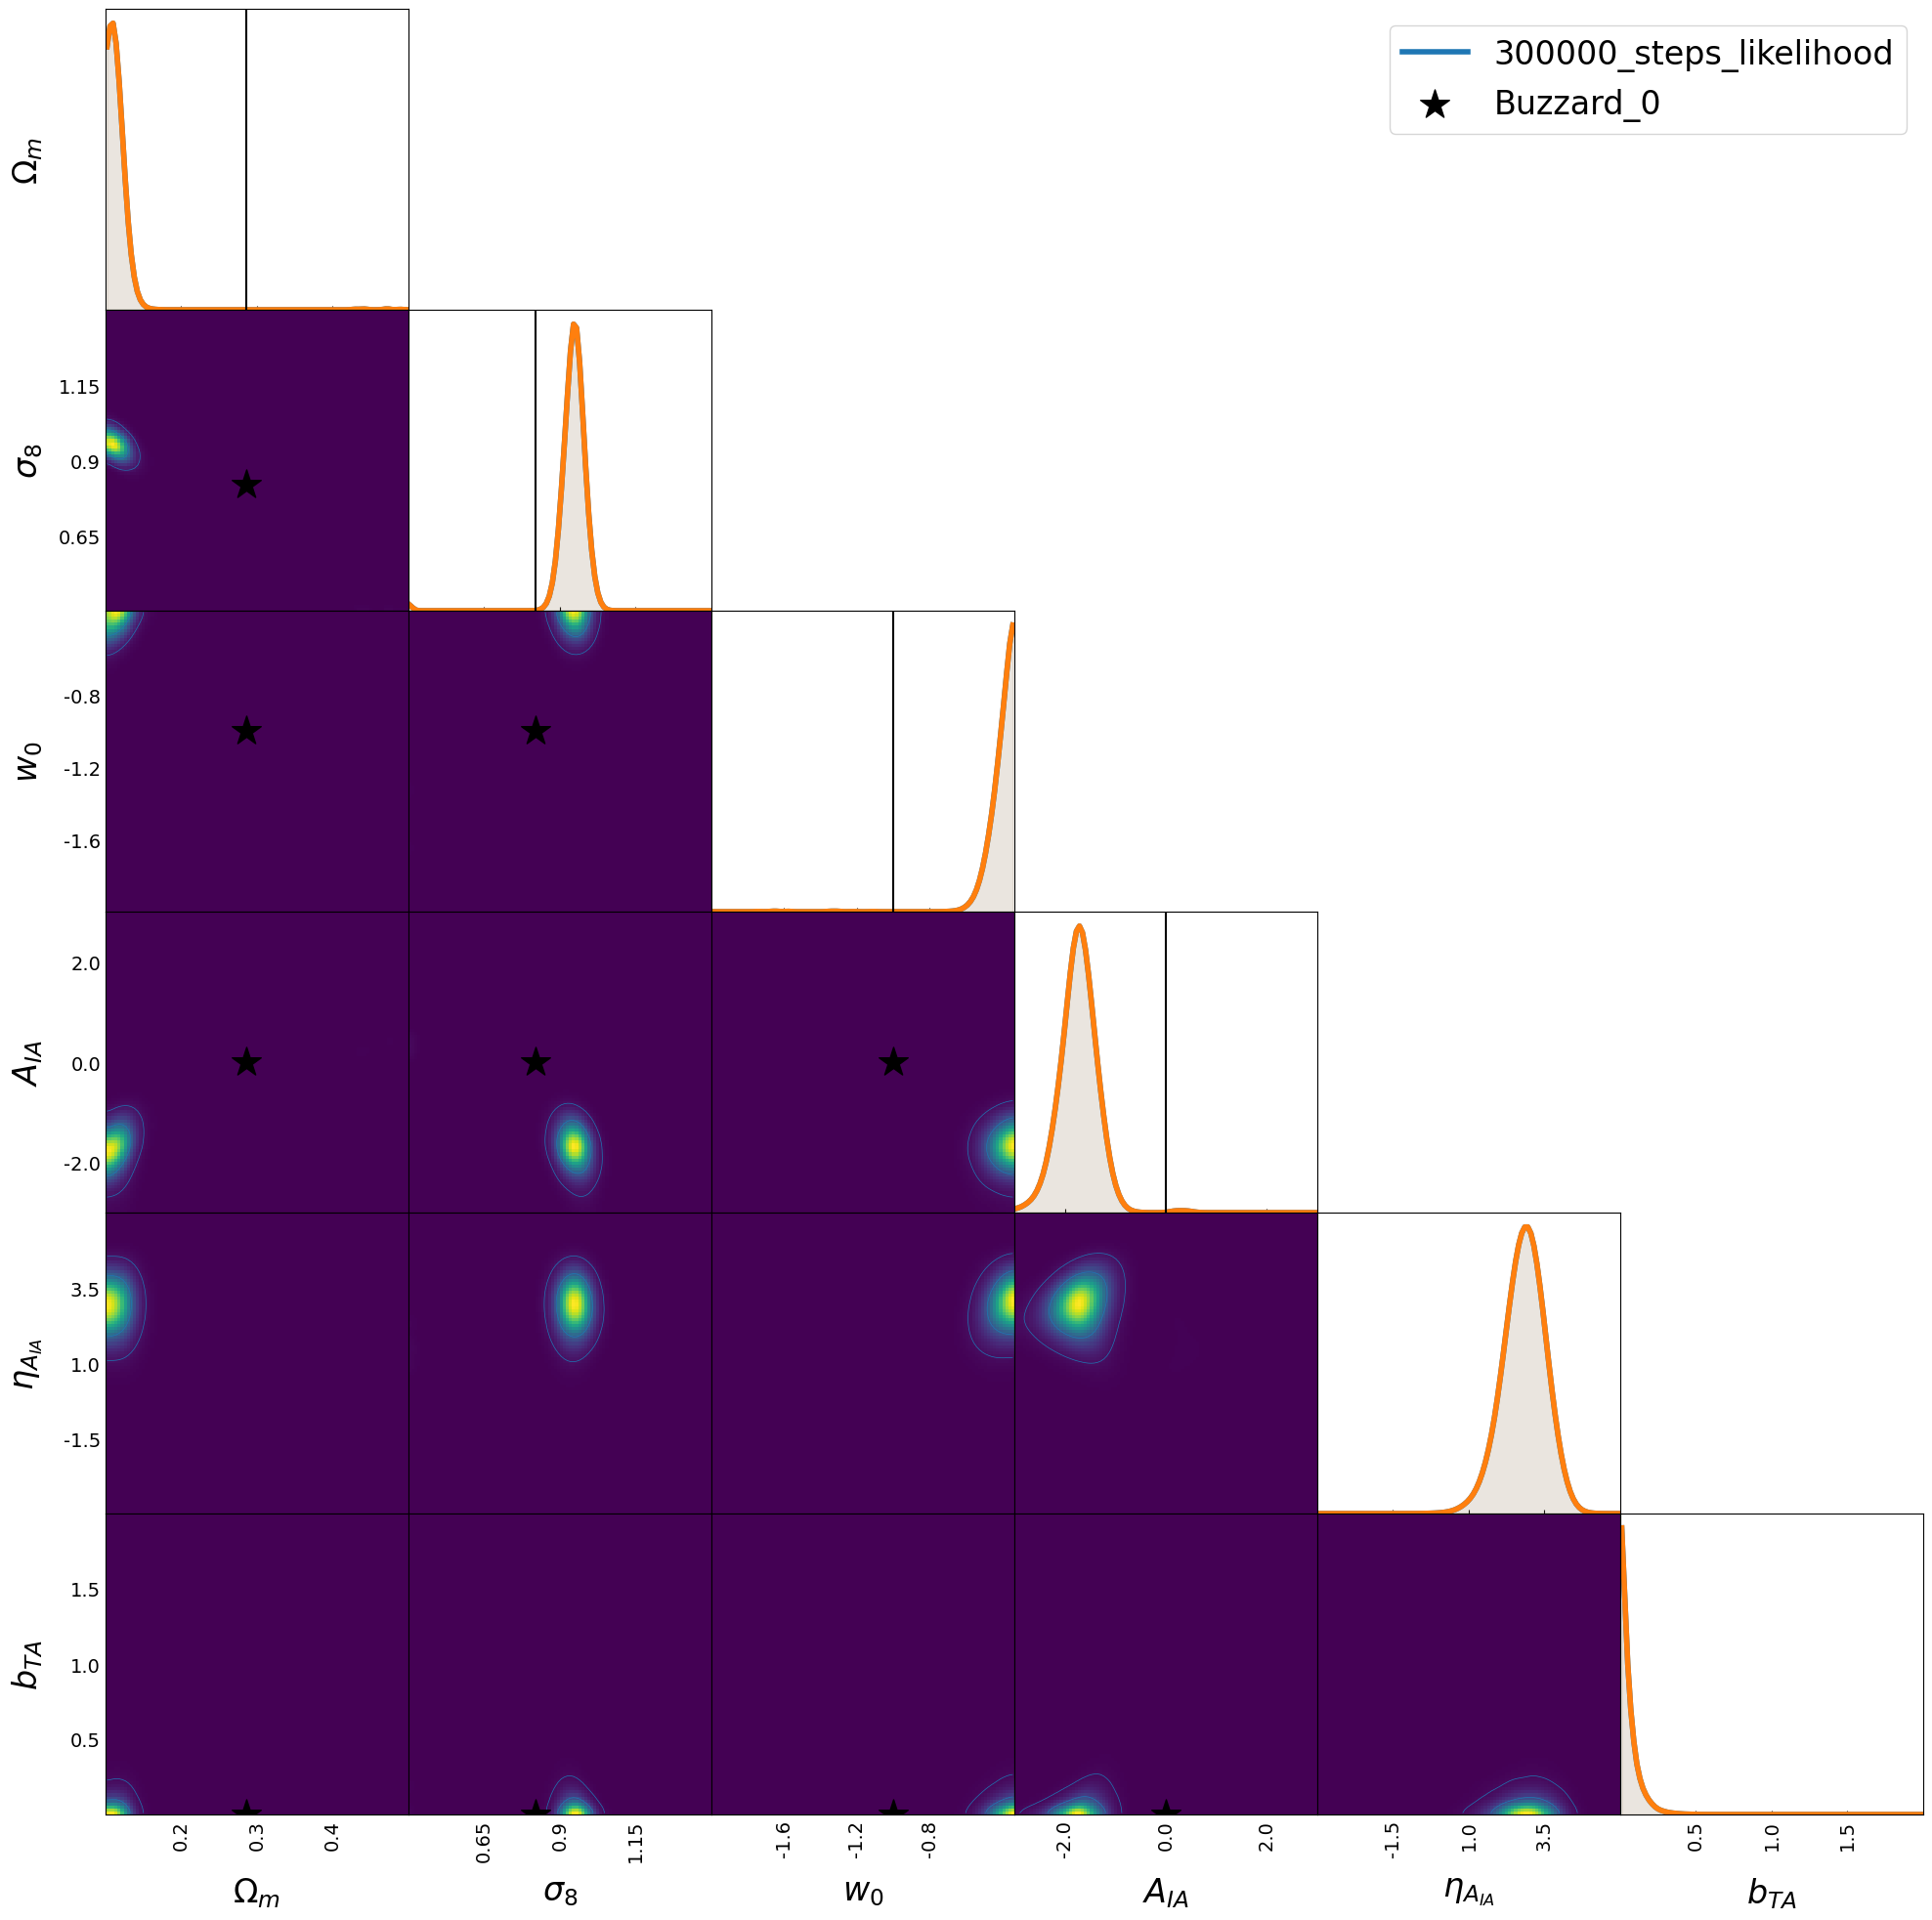

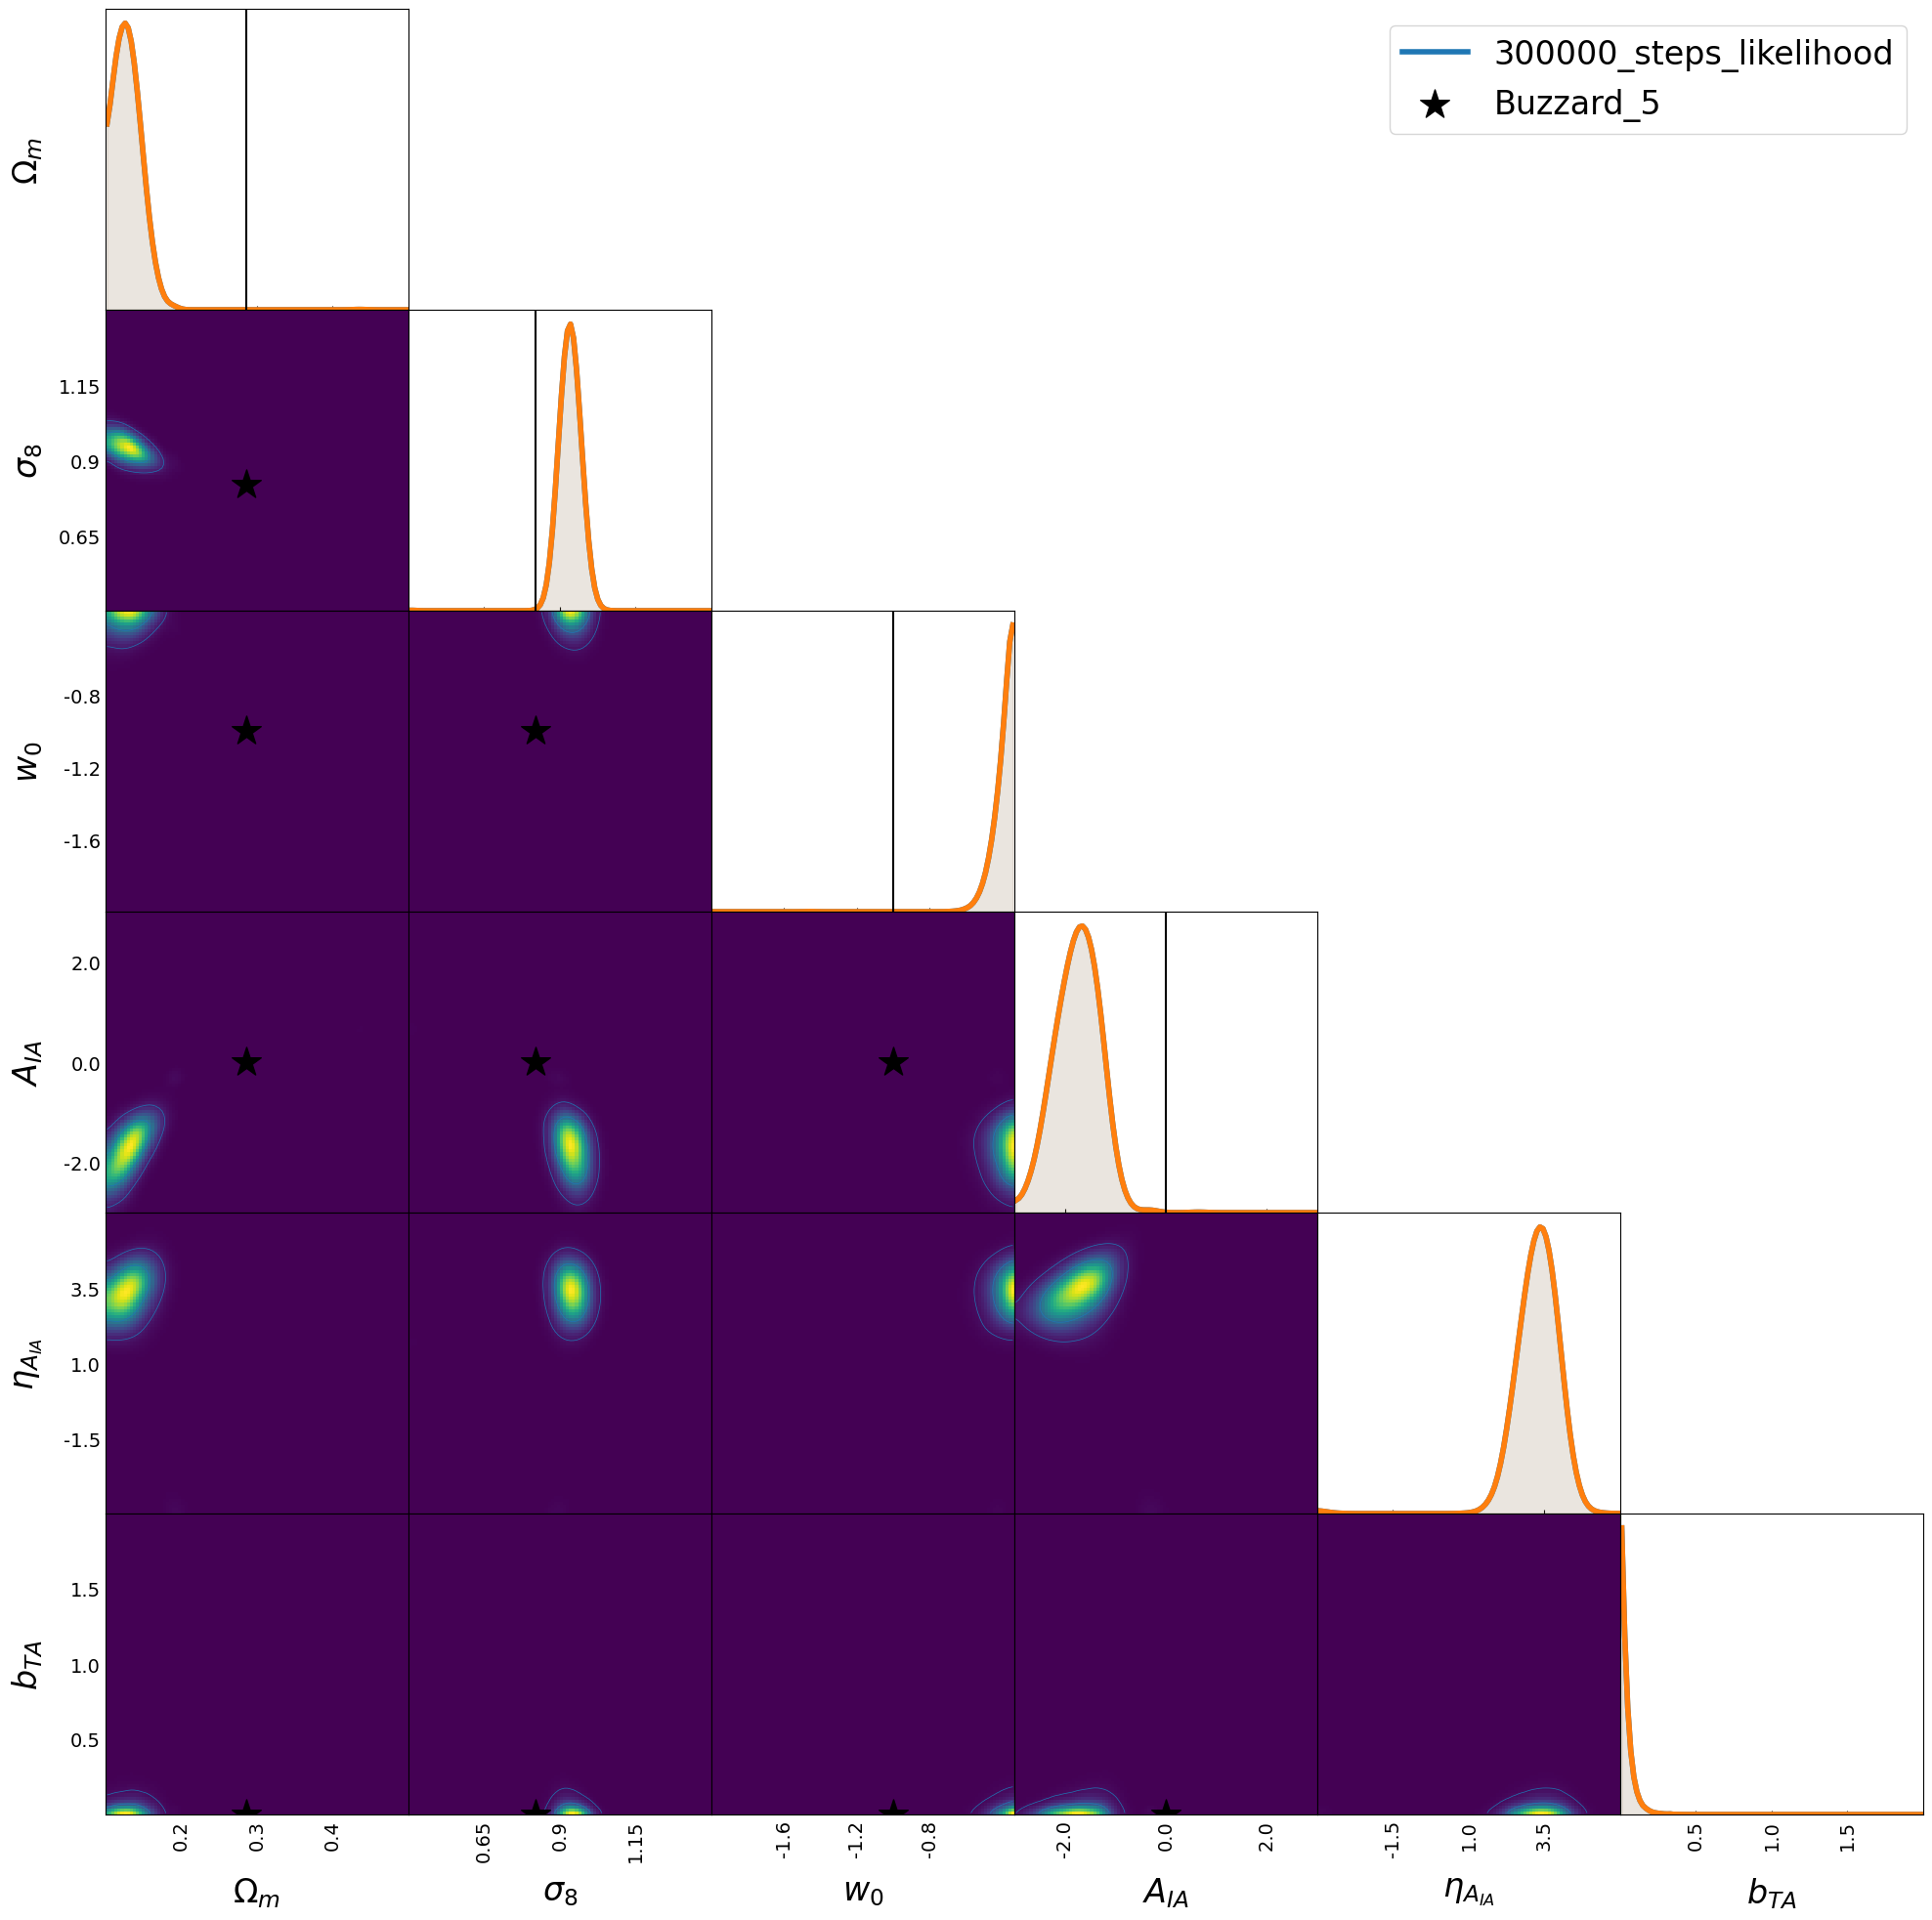

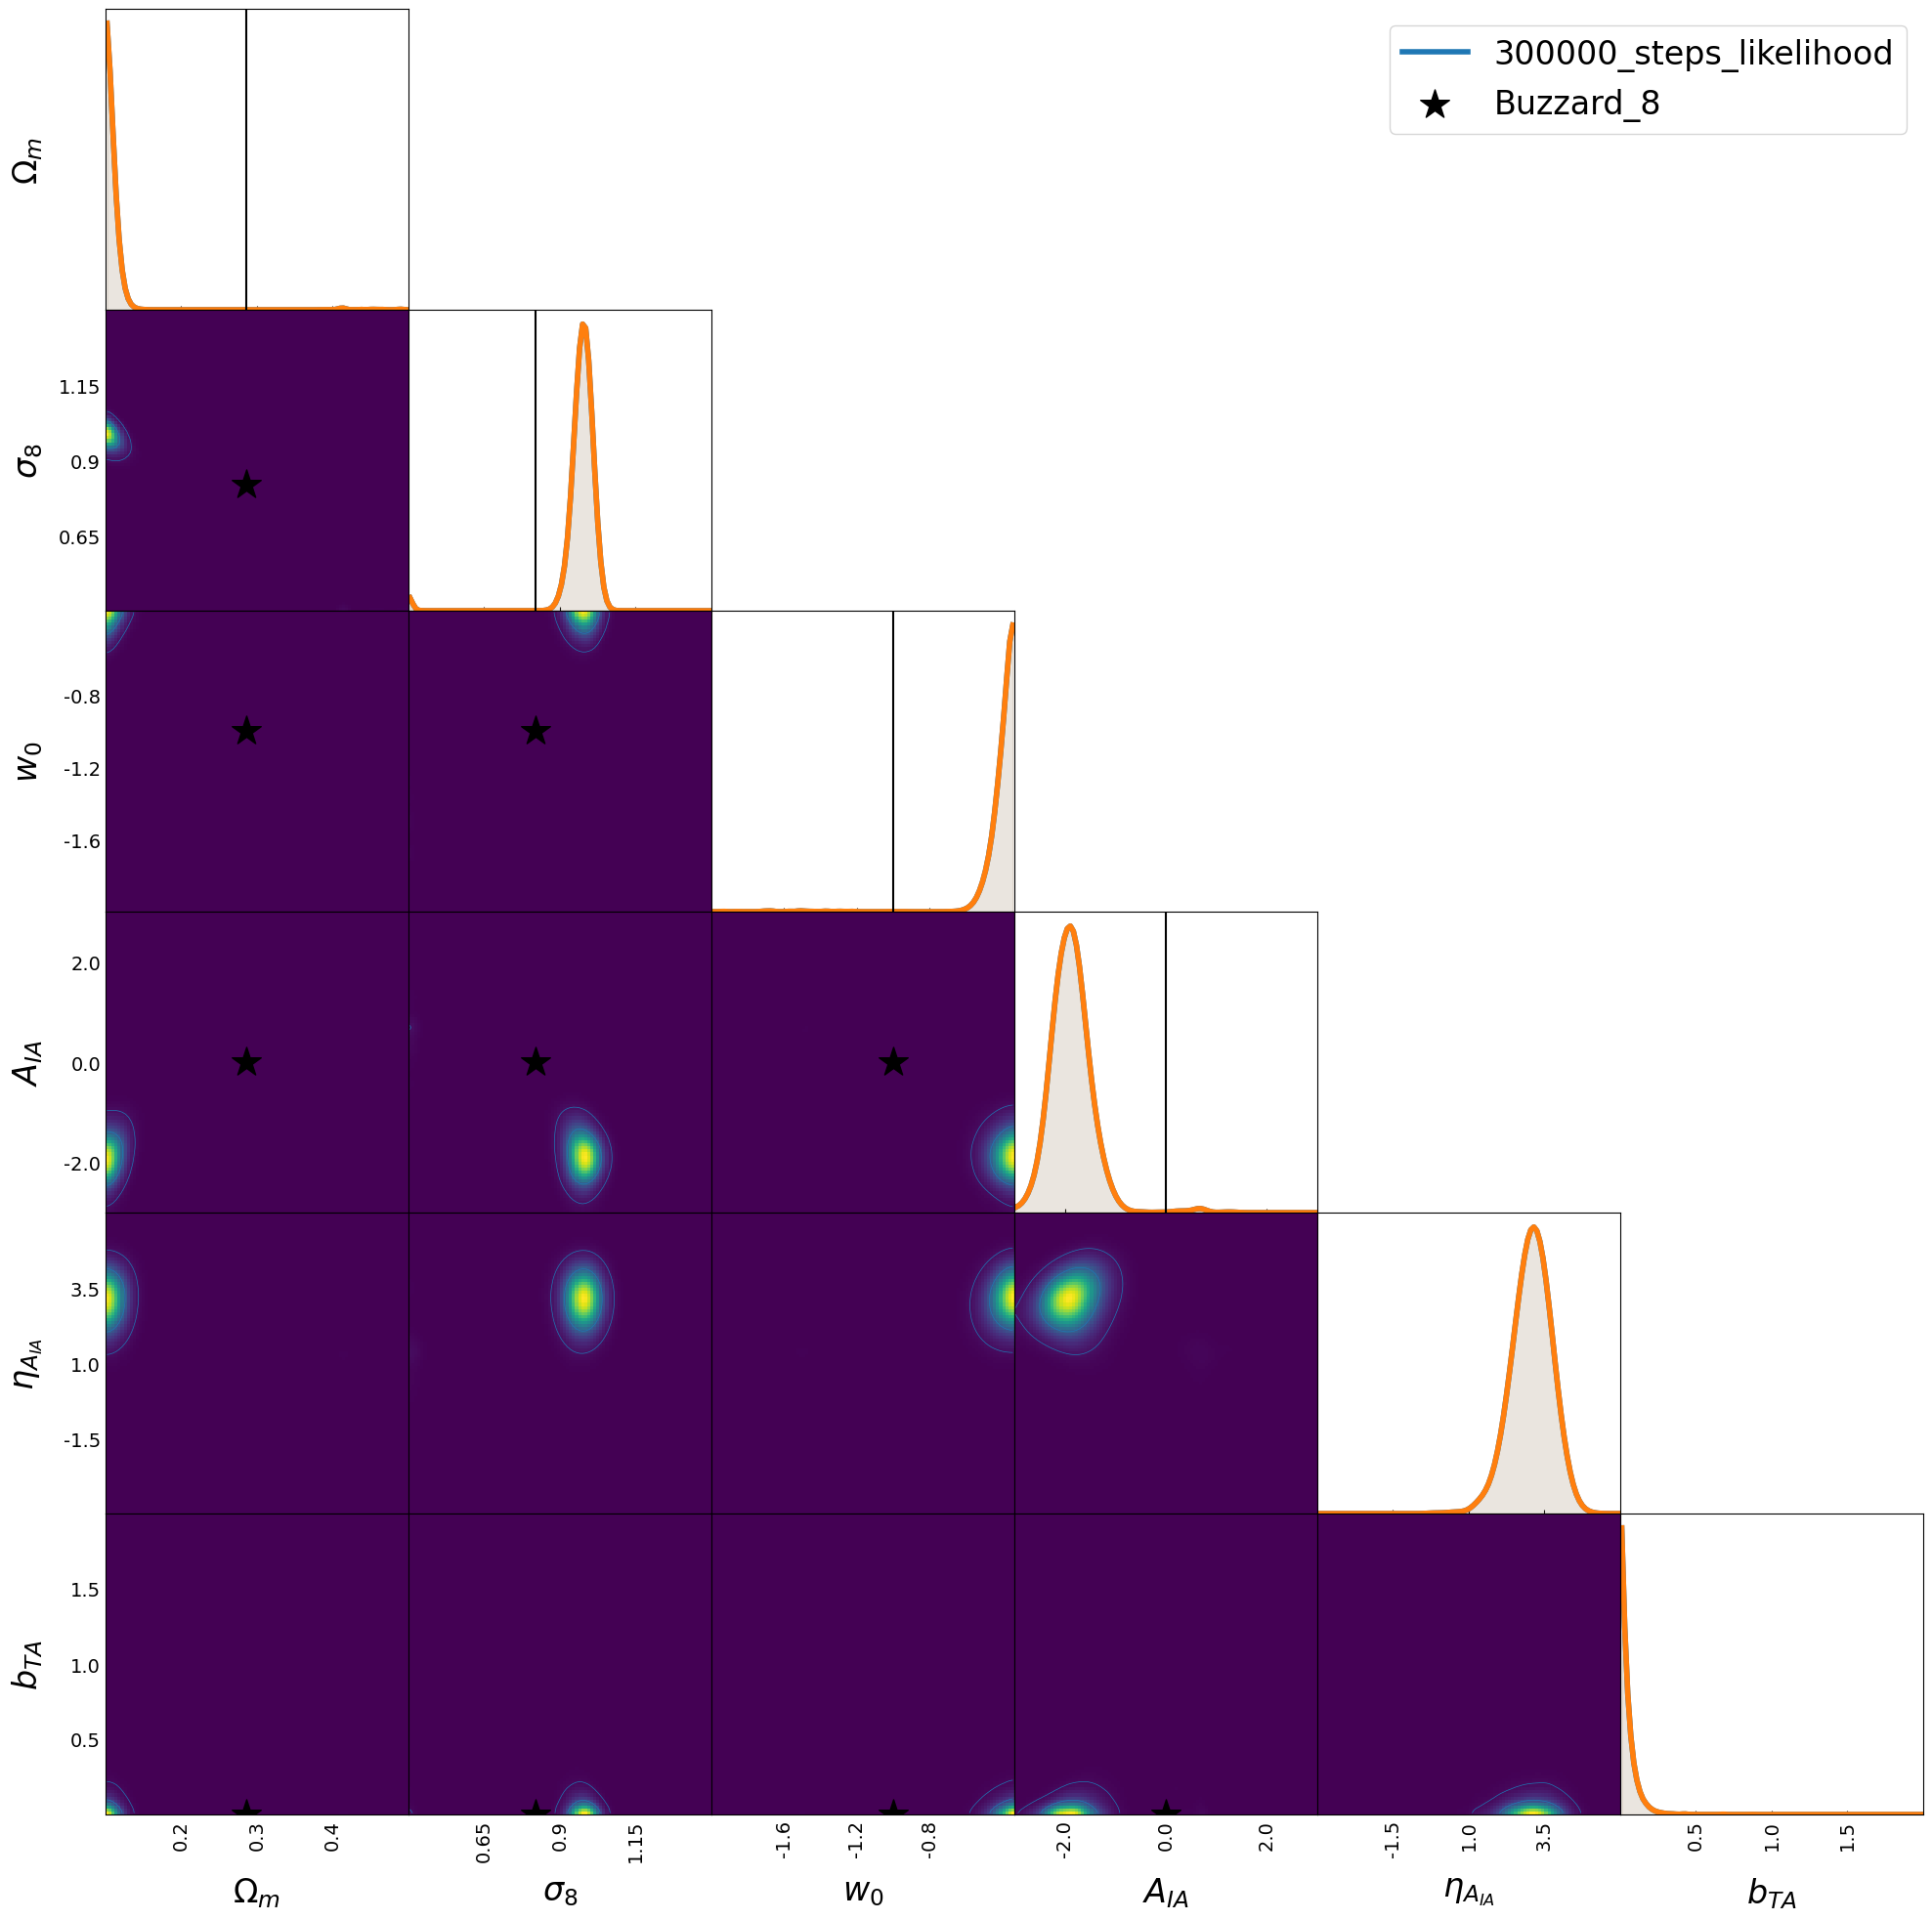

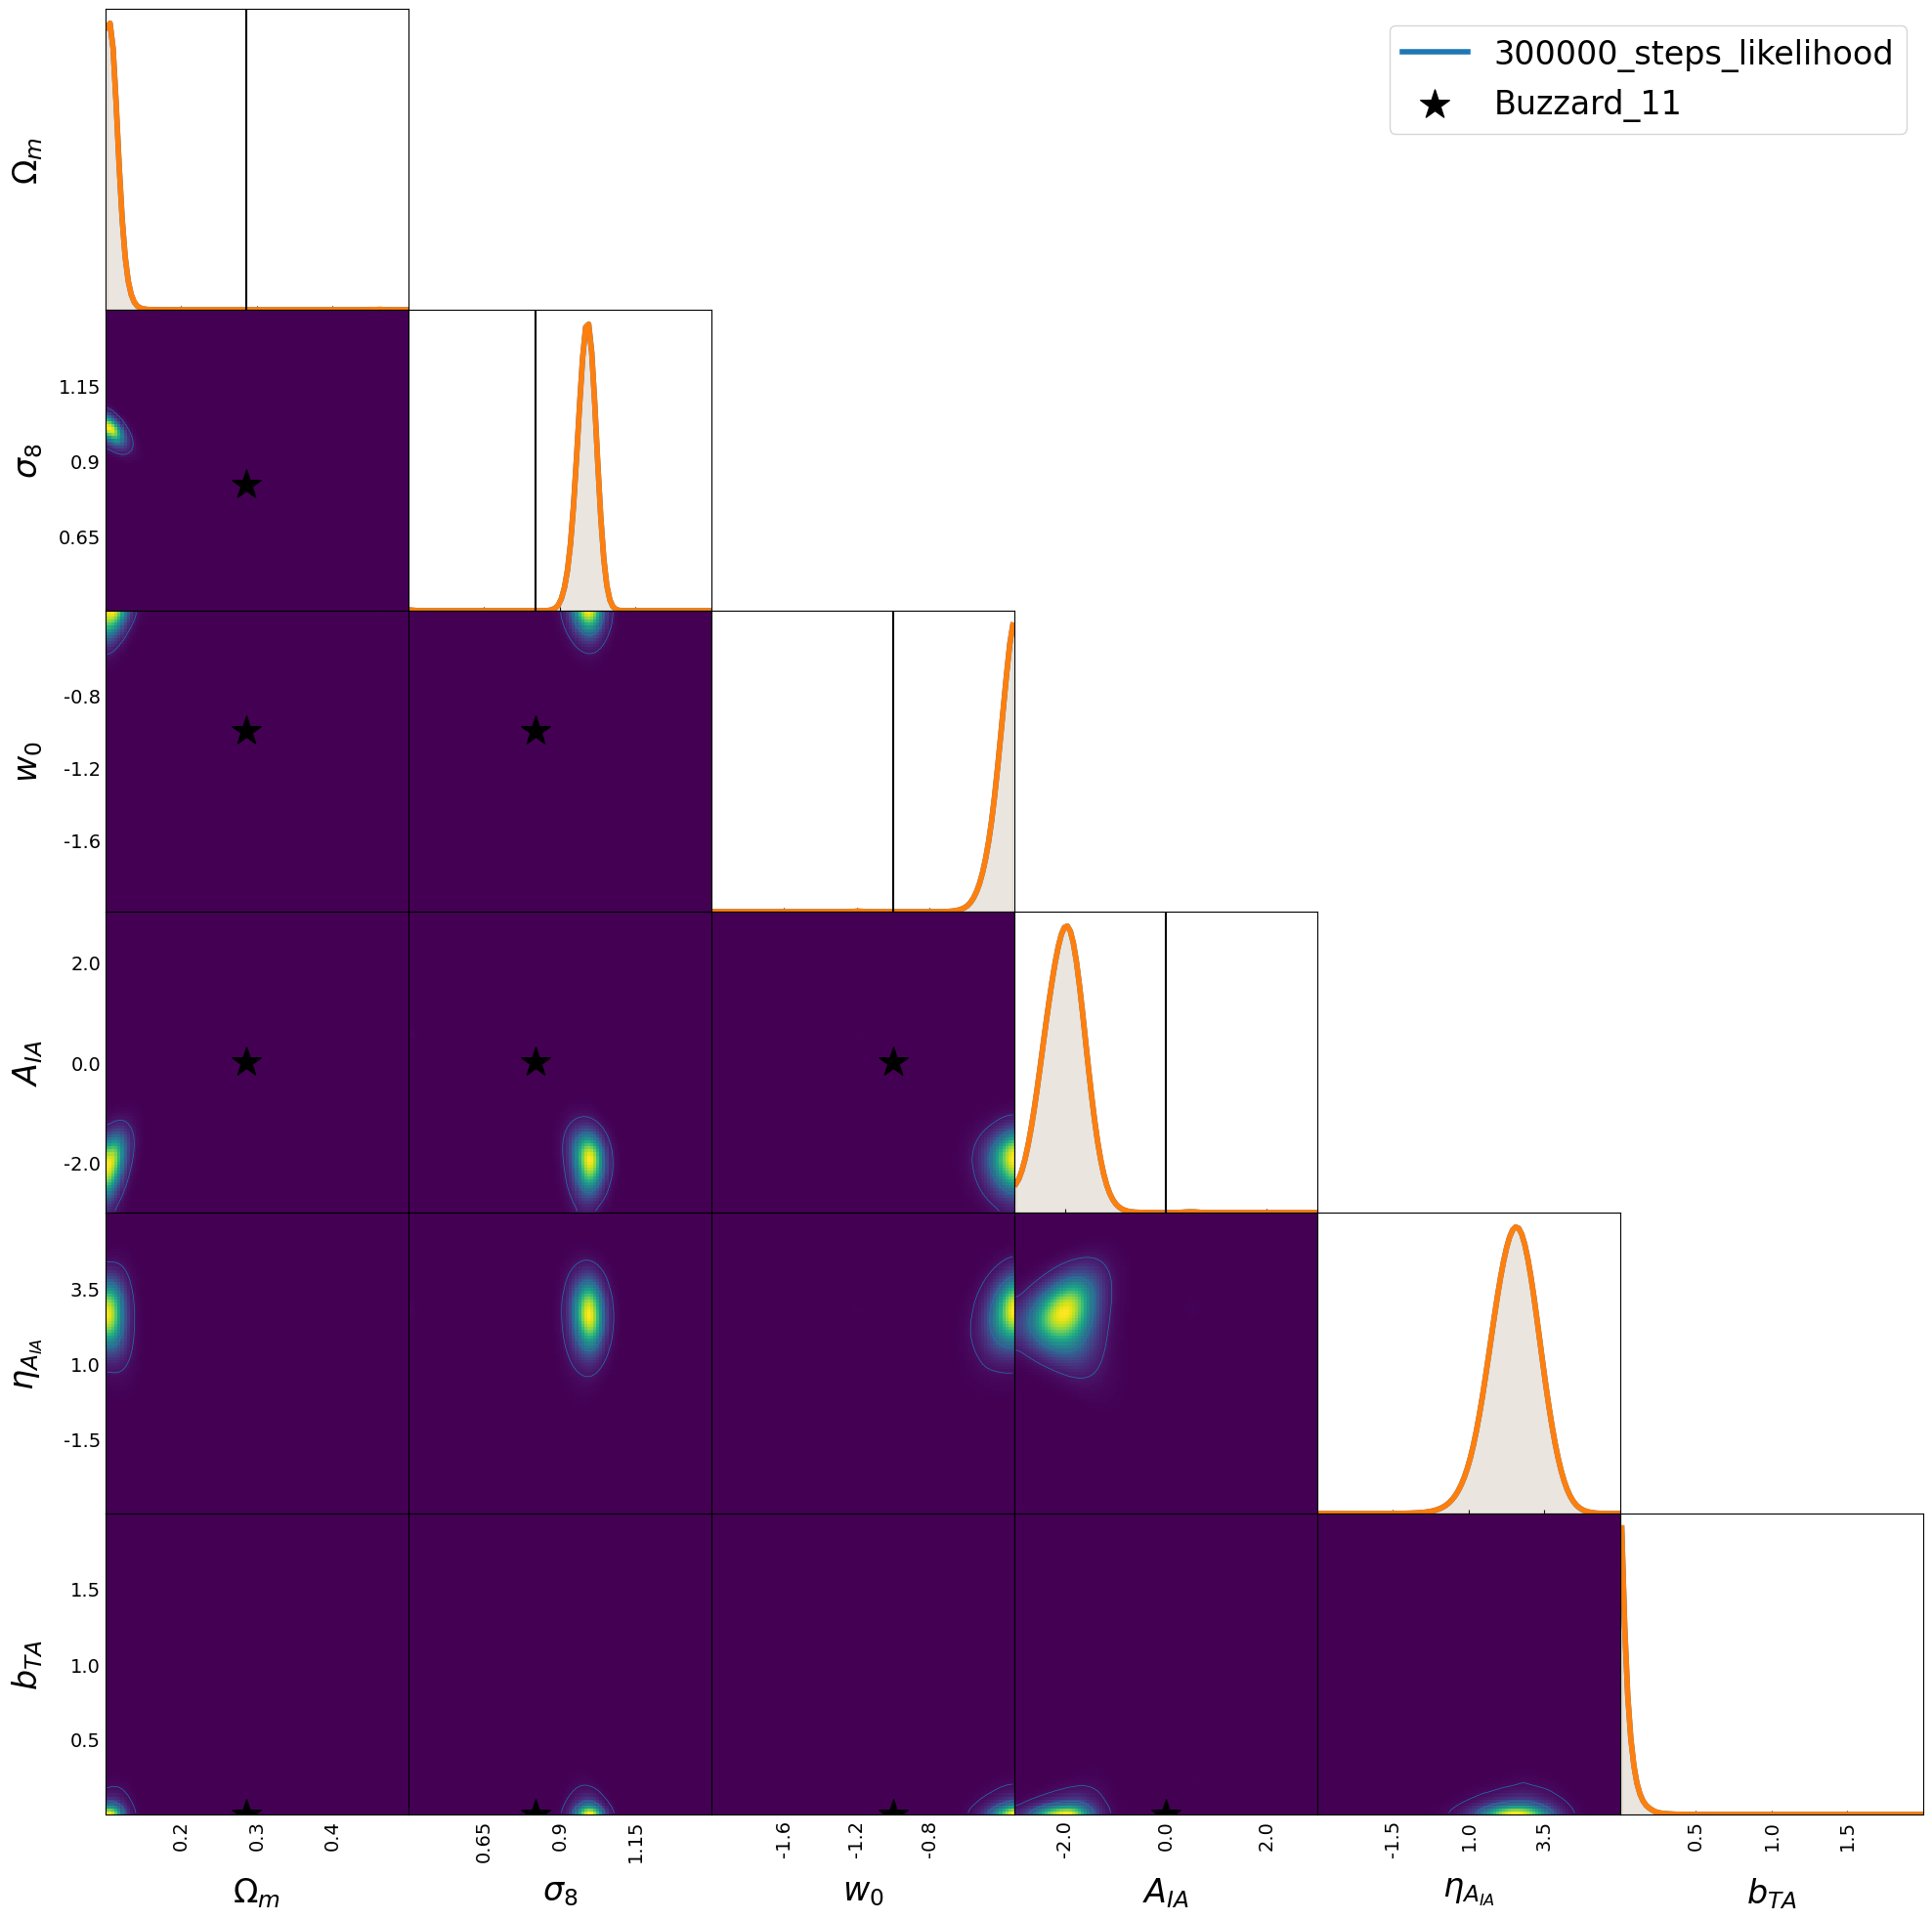

In [40]:
extra_label = ""
# extra_label = f"_{n_examples}_mocks"
# extra_label = f"_9_mocks"
# extra_label = f"_{n_examples}_mocks_shift_{shift}"

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    # print(obs_dict[key]["pred"])
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        # n_walkers=8096,
        n_burnin_steps=500,
        n_samples=1024*1000,
        # n_samples=8096*500,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key+extra_label,
        with_des_chain=False,
        density=True,
    )

### sample the posterior directly

In [41]:
# extra_label = f"_direct_{n_examples}_mocks_shift_{shift}"

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=100_000, batch_size=None, return_numpy=True)
#     posterior_samples = np.squeeze(posterior_samples)
    
#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )
    
#     samples_file = os.path.join(model.model_dir, f"chain_{key}{extra_label}.npy")
#     print(samples_file)
#     np.save(samples_file, posterior_samples)

# old